In [2]:
import glob
import os
import librosa
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
import tensorflow as tf
from tensorflow.keras import layers, models

# Path to the metadata file
metadata_file_path = r'D:\download\Compressed\DF-keys-full\keys\DF\CM\trial_metadata.txt'

# Dictionary to hold file identifiers and labels
labels = {}

# Open and read the metadata file
with open(metadata_file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_identifier = parts[1]  # Example: DF_E_2000011
        label = parts[5]            # Example: "spoof"
        labels[file_identifier] = label

# Directory containing the undersampled audio files
undersampled_audio_dir = r'D:\audio_files\undersampled_audio'

# Find all .flac files in the undersampled directory
audio_files = glob.glob(os.path.join(undersampled_audio_dir, '*.flac'))

# Create a list to store only those files that have corresponding labels in the metadata
valid_audio_files = []
valid_labels = []

# Loop through the audio files and match with metadata labels
for audio_file in audio_files:
    file_name = os.path.basename(audio_file)
    file_identifier = file_name.split('.')[0]  # Extract the file identifier (before the extension)

    # Check if the file identifier exists in the metadata labels
    if file_identifier in labels:
        valid_audio_files.append(audio_file)  # Keep this audio file
        valid_labels.append(labels[file_identifier])  # Store the corresponding label (spoof/bonafide)

# Print the number of matching files
print(f"Found {len(valid_audio_files)} audio files with corresponding labels.")

# Audio to MFCC conversion function
def audio_to_mfcc(audio_file, sr=22050, n_mfcc=13):
    """Convert audio to MFCC."""
    audio, sample_rate = librosa.load(audio_file, sr=sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return mfcc

# Resize the MFCC to a fixed size function
def resize_spectrogram(spectrogram, target_size=(128, 128)):
    """Resize the MFCC to a fixed size."""
    return cv2.resize(spectrogram, target_size)

# Preprocessing the audio files
def preprocess_audio_files(audio_files, labels, target_size=(128, 128)):
    """Convert audio files to MFCCs, resize, and normalize them."""
    mfcc_data = []
    label_data = []

    for audio_file, label in zip(audio_files, labels):
        mfcc = audio_to_mfcc(audio_file)
        resized_mfcc = resize_spectrogram(mfcc, target_size)
        
        # Safe normalization: Check if the max value is 0
        max_value = np.max(resized_mfcc)
        if max_value > 0:
            normalized_mfcc = resized_mfcc / max_value
        else:
            normalized_mfcc = resized_mfcc  # Leave it as is if the max is 0

        mfcc_data.append(normalized_mfcc)
        label_data.append(1 if label == 'spoof' else 0)  # Binary label (1: spoof, 0: bonafide)

    return np.array(mfcc_data), np.array(label_data)

# Preprocess the valid audio files and labels
X, y = preprocess_audio_files(valid_audio_files, valid_labels, target_size=(128, 128
                                                                            ))

# Add a channel dimension for CNN
X = np.expand_dims(X, axis=-1)



Found 45234 audio files with corresponding labels.


In [3]:
# Stratified 70:30 train-test split
def stratified_split_70_30(X, y, test_size=0.3, random_state=42):
    """Split dataset into stratified 70/30 sets."""
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    
    for train_idx, test_idx in strat_split.split(X, y):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
    
    # Ensure that the training set has balanced classes
    class_counts = np.bincount(y_train)
    min_class_count = min(class_counts)
    spoof_indices = np.where(y_train == 1)[0][:min_class_count]
    bonafide_indices = np.where(y_train == 0)[0][:min_class_count]
    balanced_train_indices = np.concatenate([spoof_indices, bonafide_indices])
    X_train_balanced, y_train_balanced = X_train[balanced_train_indices], y_train[balanced_train_indices]

    return X_train_balanced, X_test, y_train_balanced, y_test

# Perform the stratified 80/30 split
X_train, X_test, y_train, y_test = stratified_split_70_30(X, y, test_size=0.3, random_state=42)

# Print the distribution of classes to verify stratification
print(f"Training set distribution: {np.bincount(y_train)}")
print(f"Test set distribution: {np.bincount(y_test)}")

Training set distribution: [15831 15831]
Test set distribution: [6786 6785]


d:\download\fyp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 113s 111ms/step - accuracy: 0.7427 - loss: 0.6131 - val_accuracy: 0.7873 - val_loss: 0.4789
Epoch 2/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 107s 108ms/step - accuracy: 0.7829 - loss: 0.5010 - val_accuracy: 0.8100 - val_loss: 0.4365
Epoch 3/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 102s 102ms/step - accuracy: 0.8055 - loss: 0.4622 - val_accuracy: 0.8318 - val_loss: 0.4144
Epoch 4/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 97s 98ms/step - accuracy: 0.8227 - loss: 0.4338 - val_accuracy: 0.8476 - val_loss: 0.4141
Epoch 5/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 103s 104ms/step - accuracy: 0.8440 - loss: 0.4088 - val_accuracy: 0.8625 - val_loss: 0.3677
Epoch 6/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 107s 108ms/step - accuracy: 0.8589 - loss: 0.3849 - val_accuracy: 0.8903 - val_loss: 0.3426
Epoch 7/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 103s 104ms/step - accuracy: 0.8690 - loss: 0.3688 - val_accuracy: 0.8888 - val_loss: 0.3439
Epoch 8/100
990/990 ━━━━━━━━━━━━━━━━━━━━ 103s 104ms/step - accuracy: 0.

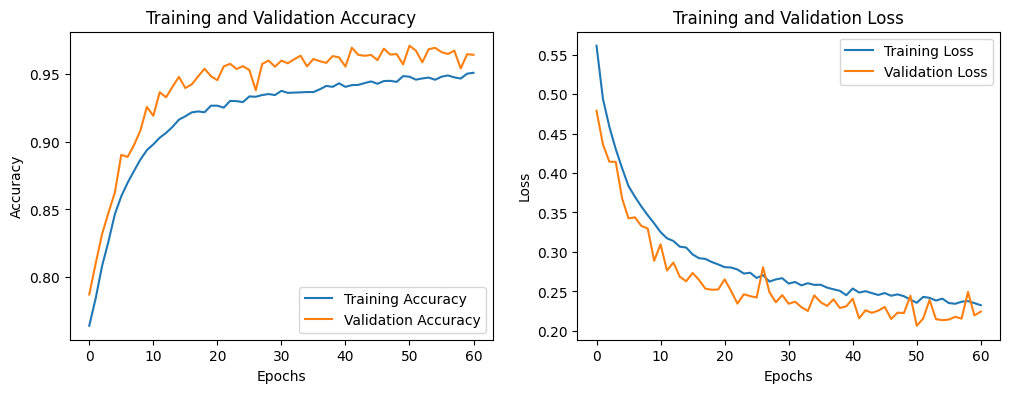

In [4]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Convert X_train and X_test to 3-channel RGB by duplicating the single channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # Shape will be (num_samples, 200, 200, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)    # Shape will be (num_samples, 200, 200, 3)

# Convert to TensorFlow tensors
X_train_rgb = tf.convert_to_tensor(X_train_rgb, dtype=tf.float32)
X_test_rgb = tf.convert_to_tensor(X_test_rgb, dtype=tf.float32)

# Define the CNN model with adjusted parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Second Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Third Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout to reduce overfitting

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (128, 128, 3)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.0005
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping, using the RGB data
history = model.fit(X_train_rgb, y_train, epochs=100, batch_size=32, validation_data=(X_test_rgb, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 96s 187ms/step - accuracy: 0.7470 - loss: 0.6291 - val_accuracy: 0.7824 - val_loss: 0.5336
Epoch 2/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 92s 186ms/step - accuracy: 0.7928 - loss: 0.4998 - val_accuracy: 0.8153 - val_loss: 0.4582
Epoch 3/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 91s 183ms/step - accuracy: 0.8177 - loss: 0.4562 - val_accuracy: 0.8493 - val_loss: 0.3952
Epoch 4/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 91s 184ms/step - accuracy: 0.8414 - loss: 0.4229 - val_accuracy: 0.8647 - val_loss: 0.3953
Epoch 5/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.8623 - loss: 0.3876 - val_accuracy: 0.8896 - val_loss: 0.3514
Epoch 6/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 81s 163ms/step - accuracy: 0.8839 - loss: 0.3583 - val_accuracy: 0.9008 - val_loss: 0.3437
Epoch 7/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 88s 179ms/step - accuracy: 0.8954 - loss: 0.3424 - val_accuracy: 0.9143 - val_loss: 0.3200
Epoch 8/100
495/495 ━━━━━━━━━━━━━━━━━━━━ 100s 201ms/step - accuracy: 0.9139 

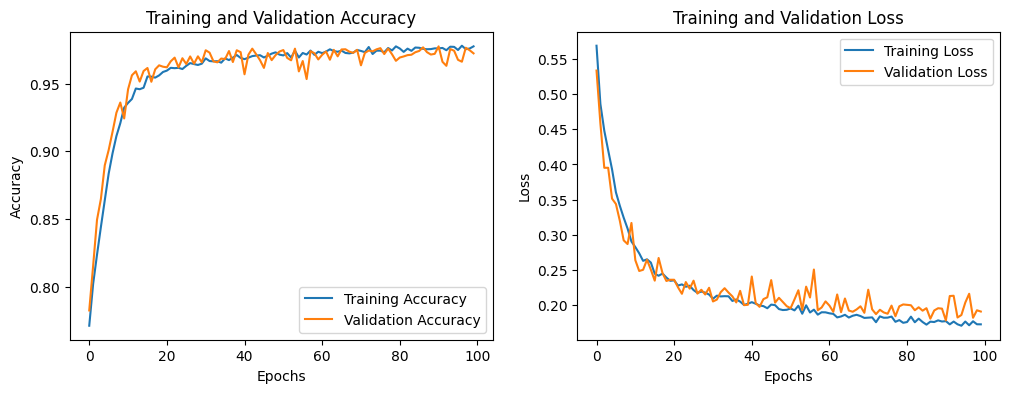

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Convert X_train and X_test to 3-channel RGB by duplicating the single channel
X_train_rgb = np.repeat(X_train, 3, axis=-1)  # Shape will be (num_samples, 200, 200, 3)
X_test_rgb = np.repeat(X_test, 3, axis=-1)    # Shape will be (num_samples, 200, 200, 3)

# Convert to TensorFlow tensors
X_train_rgb = tf.convert_to_tensor(X_train_rgb, dtype=tf.float32)
X_test_rgb = tf.convert_to_tensor(X_test_rgb, dtype=tf.float32)

# Define the CNN model with adjusted parameters to reduce overfitting
def create_cnn_model(input_shape):
    model = tf.keras.Sequential()

    # First Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Second Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Third Conv layer with more filters
    model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.MaxPooling2D((2, 2)))

    
    # Flatten and add fully connected layers with increased dropout
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(tf.keras.layers.Dropout(0.4))  # Increased dropout to reduce overfitting

    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    return model

# Create the model with the modified parameters
input_shape = (128, 128, 3)  # Shape of input (height, width, channels)
model = create_cnn_model(input_shape)

# Set a custom learning rate
learning_rate = 0.0005
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with the custom learning rate
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping, using the RGB data
history = model.fit(X_train_rgb, y_train, epochs=100, batch_size=64, validation_data=(X_test_rgb, y_test), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_rgb, y_test)
print(f"Test accuracy: {test_accuracy:.2f}")

# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [7]:
model.save('0.98.70.keras')


In [15]:
# Load necessary libraries
import numpy as np
import cv2
import librosa

# Function to preprocess a single audio file to match the input format
def preprocess_single_audio(audio_file, target_size=(128, 128)):
    """Process a single audio file for prediction."""
    # Convert audio to MFCC features
    mfcc = audio_to_mfcc(audio_file)
    resized_mfcc = resize_spectrogram(mfcc, target_size)
    
    # Safe normalization
    max_value = np.max(resized_mfcc)
    if max_value > 0:
        normalized_mfcc = resized_mfcc / max_value
    else:
        normalized_mfcc = resized_mfcc
    
    # Expand dimensions to add batch size of 1 and single channel, then convert to RGB (3 channels)
    single_input = np.expand_dims(normalized_mfcc, axis=-1)  # Shape (128, 128, 1)
    single_input_rgb = np.repeat(single_input, 3, axis=-1)   # Shape (128, 128, 3)
    single_input_rgb = np.expand_dims(single_input_rgb, axis=0)  # Shape (1, 128, 128, 3)
    
    return single_input_rgb

# Define the path to the single unseen file
single_audio_file_path = r"C:\Users\Hariz\Downloads\test1.wav"  # Replace with your file path

# Preprocess the single unseen file
single_input_rgb = preprocess_single_audio(single_audio_file_path, target_size=(128, 128))

# Make a prediction
predicted_probabilities = model.predict(single_input_rgb)
predicted_class = np.argmax(predicted_probabilities, axis=-1)  # Get the predicted label
confidence_score = np.max(predicted_probabilities)  # Get the confidence score

# Map prediction to label names if needed (e.g., 1 for "spoof" and 0 for "bonafide")
label_map = {0: "bonafide", 1: "spoof"}
predicted_label = label_map[predicted_class[0]]

# Output results
print(f"Predicted Label: {predicted_label}")
print(f"Confidence Score: {confidence_score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Label: bonafide
Confidence Score: 0.10


In [17]:
# Load necessary libraries
import numpy as np
import cv2
import librosa

# Function to preprocess a single audio file to match the input format
def preprocess_single_audio(audio_file, target_size=(128, 128)):
    """Process a single audio file for prediction."""
    # Convert audio to MFCC features
    mfcc = audio_to_mfcc(audio_file)
    resized_mfcc = resize_spectrogram(mfcc, target_size)
    
    # Safe normalization
    max_value = np.max(resized_mfcc)
    if max_value > 0:
        normalized_mfcc = resized_mfcc / max_value
    else:
        normalized_mfcc = resized_mfcc
    
    # Expand dimensions to add batch size of 1 and single channel, then convert to RGB (3 channels)
    single_input = np.expand_dims(normalized_mfcc, axis=-1)  # Shape (128, 128, 1)
    single_input_rgb = np.repeat(single_input, 3, axis=-1)   # Shape (128, 128, 3)
    single_input_rgb = np.expand_dims(single_input_rgb, axis=0)  # Shape (1, 128, 128, 3)
    
    return single_input_rgb

# Define the path to the single unseen file
single_audio_file_path = r"C:\Users\Hariz\Downloads\fakeyou_n0ht2fpe3rcmdn0hr3p12ad159xfrzrf.wav"  # Replace with your file path

# Preprocess the single unseen file
single_input_rgb = preprocess_single_audio(single_audio_file_path, target_size=(128, 128))

# Make a prediction
predicted_probabilities = model.predict(single_input_rgb)
predicted_class = np.argmax(predicted_probabilities, axis=-1)  # Get the predicted label
confidence_score = np.max(predicted_probabilities)  # Get the confidence score

# Map prediction to label names if needed (e.g., 1 for "spoof" and 0 for "bonafide")
label_map = {0: "bonafide", 1: "spoof"}
predicted_label = label_map[predicted_class[0]]

# Output results
print(f"Predicted Label: {predicted_label}")
print(f"Confidence Score: {confidence_score:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Label: bonafide
Confidence Score: 0.71
